# Unconstrained: $J=0$ vs a constant $J$, on each regularizer

The unconstrained scheme, with no projection:

$$x_{k+1}=x_k-\eta\,a(x_k)\nabla U_0(x_k)
+\eta\,\alpha\,e^{U(x_k)}J\,\nabla\psi(x_k)
+\sqrt{2\eta\,a(x_k)}\,\xi_{k+1},\qquad a(x)=e^{U(x)-U_0(x)},$$

with $U=f+g$, $U_0=f+g_0$, and $g_0$ from the closed-form piecewise-quadratic lemma. Comparison is
$\alpha=0$ against a **constant** skew $J$, on Lasso, MCP and SCAD.

$\alpha$ is held **fixed** throughout: no annealing schedule, so the skew drift $\alpha J$ is genuinely
constant in time as well as in space. That makes "which $\alpha$?" the live tuning question, and
Experiment 1 sweeps it over $\{1,2,4,8\}$ on both candidate axes.

## Removing $K$ removes $\psi$, and that is not a formality

In the constrained problem $\psi=(\lambda-G)h$ was pinned to the constraint set: $K=\{G\le\lambda\}$ gave it
both its zero level set and its boundary-normal gradient. With no $K$ there is no such $\psi$, and one has
to be chosen. Invariance alone is easy — for a **constant** skew $J$,
$$\nabla\!\cdot(J\nabla\psi)=\sum_{ij}J_{ij}\,\partial_i\partial_j\psi=0$$
for *any* $\psi$, antisymmetric contracted with symmetric. There is no boundary condition to satisfy,
because there is no boundary. So every $\psi$ is admissible.

**But not every $\psi$ is usable.** On a compact $K$ the factor $e^{U}$ is bounded, so the skew drift is
bounded whatever $\psi$ is. On $\mathbb R^d$, $e^{U}$ is *unbounded* — here $U\supset\tfrac12x^\top\Sigma^{-1}x$,
so $e^{U}$ grows like $e^{\lVert x\rVert^2}$. Carrying over the constrained choice $\psi=-\tfrac12\lVert
x\rVert^2$ (i.e. $\nabla\psi=-x$) gives a drift $\propto e^{U}x$ that overflows to `inf` within a few
hundred steps, which is demonstrated below rather than asserted.

The fix is to temper $\psi$ against the same exponential. Taking
$$\psi=-e^{-U_0}\quad\Longrightarrow\quad \nabla\psi=e^{-U_0}\nabla U_0
\quad\Longrightarrow\quad \alpha e^{U}J\nabla\psi=\alpha\,e^{U-U_0}J\nabla U_0=\alpha\,a(x)\,J\nabla U_0,$$
so the skew drift is the reversible one times $\alpha$, rotated — and bounded **because $a$ is bounded**,
which needs an argument (see below; it is *not* simply $a\le1$). The update collapses to

$$x_{k+1}=x_k-\eta\,a(x_k)\bigl(I+\alpha J\bigr)\nabla U_0(x_k)+\sqrt{2\eta\,a(x_k)}\,\xi_{k+1},$$

which is exactly **anchored non-reversible Langevin** — the $J$ acting on $\nabla U_0$ of the early
notebooks. So the two formulations are not rivals: on a constrained set $J$ must act on $\nabla\psi$ to get
tangency, and unconstrained the natural $\psi$ puts it back on $\nabla U_0$. The apparent conflict was an
artefact of the boundary.

---

### What is different in this version

Three things, beyond re-running the same experiments.

1. **A correction.** The bound $a\in(0,1]$ holds only for a *convex* penalty. It is false for MCP and
   SCAD, both non-convex by construction. The replacement is exact rather than approximate, and the
   conclusion survives.
2. **Error bars.** The headline speed-ups were three seeds with no uncertainty attached. Replicas here are
   run as one batched ensemble, which makes twelve of them affordable, and every speed-up is quoted with a
   bootstrap interval. One of the three original claims does not survive this.
3. **A control for the stationary gap.** The claim that the small $W_1$ penalty at stationarity is
   "ordinary discretization, not a broken fixed point" is now measured — by refining $\eta$ at fixed
   physical time — instead of asserted.

In [1]:
%matplotlib inline
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import ks_2samp, wasserstein_distance

torch.set_default_dtype(torch.float64)
os.makedirs("figures", exist_ok=True)

SQRT2 = math.sqrt(2.0)
INV_SQRT_2PI = 1.0 / math.sqrt(2.0 * math.pi)


def Phi(u):
    return 0.5 * (1.0 + torch.erf(u / SQRT2))


def phi(u):
    return INV_SQRT_2PI * torch.exp(-0.5 * u * u)


# +-inf-safe versions: the outermost pieces have infinite breakpoints
def PhiX(u):
    fin = torch.isfinite(u)
    step = torch.where(u > 0, torch.ones_like(u), torch.zeros_like(u))
    return torch.where(fin, Phi(torch.where(fin, u, torch.zeros_like(u))), step)


def phiX(u):
    fin = torch.isfinite(u)
    return torch.where(fin, phi(torch.where(fin, u, torch.zeros_like(u))), torch.zeros_like(u))


def uphiX(u):
    fin = torch.isfinite(u)
    uu = torch.where(fin, u, torch.zeros_like(u))
    return torch.where(fin, uu * phi(uu), torch.zeros_like(u))

## The closed-form smoothing lemma

For $p$ continuous and piecewise quadratic with $p(t)=c_{0,j}+c_{1,j}t+c_{2,j}t^2$ on $(t_j,t_{j+1})$, and
$u_j=(t_j-x)/\mu$,

$$P_j=\Phi(u_{j+1})-\Phi(u_j),\quad M_j=\phi(u_j)-\phi(u_{j+1}),\quad
Q_j=P_j+u_j\phi(u_j)-u_{j+1}\phi(u_{j+1}),$$

$$p_0(x)=\sum_j\Bigl\{(c_{0,j}+c_{1,j}x+c_{2,j}x^2)P_j+\mu(c_{1,j}+2c_{2,j}x)M_j+c_{2,j}\mu^2Q_j\Bigr\},
\qquad
p_0'(x)=\sum_j\Bigl\{(c_{1,j}+2c_{2,j}x)P_j+2c_{2,j}\mu M_j\Bigr\}.$$

One generic implementation covers all three regularizers; only the breakpoint/coefficient table changes.
It is reproduced inline here so the notebook stays self-contained; the same code, with the bound above and
a test suite pinning both, is in `ands/penalties.py`.

In [2]:
class PiecewiseQuadratic:
    def __init__(self, breaks, coefs, name=""):
        self.t = list(breaks)
        self.c = [tuple(map(float, c)) for c in coefs]
        self.name = name
        assert len(self.c) == len(self.t) + 1

    def raw(self, x):                       # the exact, non-differentiable penalty
        out = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            m = (x > ts[j]) & (x <= ts[j + 1])
            out = torch.where(m, c0 + c1 * x + c2 * x * x, out)
        return out

    def smooth(self, x, mu):                # (p0, p0') in closed form
        val = torch.zeros_like(x)
        grad = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            uj = torch.full_like(x, -math.inf) if ts[j] == -math.inf else (ts[j] - x) / mu
            uj1 = torch.full_like(x, math.inf) if ts[j + 1] == math.inf else (ts[j + 1] - x) / mu
            P = PhiX(uj1) - PhiX(uj)
            M = phiX(uj) - phiX(uj1)
            Q = P + uphiX(uj) - uphiX(uj1)
            val = val + (c0 + c1 * x + c2 * x * x) * P + mu * (c1 + 2 * c2 * x) * M + c2 * mu ** 2 * Q
            grad = grad + (c1 + 2 * c2 * x) * P + 2 * c2 * mu * M
        return val, grad

    def min_curvature(self):
        """The most negative quadratic coefficient -- 0 for a convex penalty.

        This single number controls how far the anchor can fall *below* the penalty,
        and hence how far a(x) can exceed 1.  See the next section."""
        return min(c2 for _, _, c2 in self.c)


def lasso(lam):
    return PiecewiseQuadratic([0.0], [(0., -lam, 0.), (0., lam, 0.)], "Lasso")


def mcp(lam, a):
    return PiecewiseQuadratic(
        [-a * lam, 0.0, a * lam],
        [(a * lam ** 2 / 2, 0., 0.), (0., -lam, -1 / (2 * a)),
         (0., lam, -1 / (2 * a)), (a * lam ** 2 / 2, 0., 0.)], "MCP")


def scad(lam, a):
    c = 1.0 / (2 * (a - 1))
    return PiecewiseQuadratic(
        [-a * lam, -lam, 0.0, lam, a * lam],
        [(lam ** 2 * (a + 1) / 2, 0., 0.), (-lam ** 2 * c, -2 * a * lam * c, -c), (0., -lam, 0.),
         (0., lam, 0.), (-lam ** 2 * c, 2 * a * lam * c, -c), (lam ** 2 * (a + 1) / 2, 0., 0.)], "SCAD")


LAM, AA, MU = 1.0, 3.0, 0.3
PENS = {"Lasso": lasso(LAM), "MCP": mcp(LAM, AA), "SCAD": scad(LAM, AA)}

In [3]:
# --- the closed forms are checked against Monte Carlo and against finite differences
xg = torch.linspace(-4, 4, 41)
torch.manual_seed(0)
Z = torch.randn(2_000_000)
rows = []
for P in PENS.values():
    v, g = P.smooth(xg, MU)
    vmc = torch.stack([P.raw(xi + MU * Z).mean() for xi in xg])
    se = float(torch.stack([P.raw(xi + MU * Z).std() for xi in xg]).max() / math.sqrt(len(Z)))
    h = 1e-5
    vp, _ = P.smooth(xg + h, MU)
    vm, _ = P.smooth(xg - h, MU)
    rows.append({"penalty": P.name,
                 "max |closed - MC|": "{:.2e}".format(float((v - vmc).abs().max())),
                 "max |p0' - d/dx p0|": "{:.2e}".format(float((g - (vp - vm) / (2 * h)).abs().max())),
                 "MC std err": "{:.2e}".format(se)})
print("the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed")
pd.DataFrame(rows).set_index("penalty")

the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed


,max |closed - MC|,max |p0' - d/dx p0|,MC std err
penalty,,,
Lasso,1.93e-04,7.92e-11,2.12e-04
MCP,1.75e-04,8.15e-11,1.62e-04
SCAD,1.93e-04,8.46e-11,2.06e-04


## The anchor multiplier: where $a\le 1$ is false

The tempering argument needs $a=e^{U-U_0}=e^{g-g_0}$ to be **bounded**. The natural claim is
$a\le1$, i.e. $g_0\ge g$, and that is Jensen: for a *convex* $p$,
$p_0(x)=\mathbb E\,p(x+\mu Z)\ge p(x)$.

**MCP and SCAD are not convex.** That is the entire point of them — they taper the penalty to zero for
large coefficients, which requires negative curvature. On those pieces Jensen runs the other way and the
anchor sits *below* the penalty, so $a>1$.

How far below is bounded, and the bound is a theorem rather than a fit. Let
$u(x,t)=\mathbb E\,p(x+\sqrt{2t}\,Z)$, which solves the heat equation $\partial_t u=\partial_{xx}u$ with
$u(\cdot,0)=p$, so $p_0=u(\cdot,\mu^2/2)$ and

$$p_0(x)-p(x)=\int_0^{\mu^2/2}(\partial_{xx}u)(x,s)\,ds.$$

The distributional second derivative of a continuous piecewise quadratic is $2c_2$ on each piece plus a
**non-negative atom at every convex kink**, so $\partial_{xx}u\ge2c_2^{\min}$ pointwise and

$$p_0(x)-p(x)\;\ge\;c_2^{\min}\mu^2,\qquad
\max_t\bigl(p-p_0\bigr)\;\le\;\mu^2\max\bigl(0,-c_2^{\min}\bigr),\qquad
a(x)\;\le\;\exp\Bigl(d\,\mu^2\max\bigl(0,-c_2^{\min}\bigr)\Bigr),$$

summing over the $d$ coordinates. Convex penalties have $c_2^{\min}=0$ and recover $a\le1$.

The inequality holds for every $\mu$; it is **attained** while the smoothing kernel fits inside the most
concave piece, and goes slack once $\mu$ approaches the piece width (at $\mu=1$ the true deficit is about
$0.8$ of it). At the $\mu=0.3$ used here it is attained to five digits, as the table below shows.

**Does the conclusion survive?** Yes. $a$ is still bounded by a constant of order 1, so the skew drift is
still bounded by a constant times the reversible one, and every experiment below is unaffected. What
changes is the reason: the tempering works because $g-g_0$ is *uniformly bounded*, not because the anchor
dominates. For a penalty with unbounded negative curvature it would not work at all, and the original
argument gives no way to see that.

In [4]:
d = 3
tt = torch.linspace(-8, 8, 200_001)
rows = []
for P in PENS.values():
    g = P.raw(tt)
    g0, _ = P.smooth(tt, MU)
    worst = float((g - g0).max())
    c2min = P.min_curvature()
    predicted = MU ** 2 * max(0.0, -c2min)
    rows.append({"penalty": P.name,
                 "convex": c2min >= 0,
                 "min curvature c2": round(c2min, 4),
                 "max(g - g0) measured": round(worst, 6),
                 "mu^2 * max(0, -c2)": round(predicted, 6),
                 "a <= exp(d * .)": round(math.exp(d * predicted), 4)})
print("the bound is exact: 'measured' and 'predicted' agree to grid resolution\n")
display(pd.DataFrame(rows).set_index("penalty"))
print("So a <= 1 holds for Lasso only.  For MCP and SCAD the anchor dips BELOW the penalty")
print("on the concave pieces and a exceeds 1 -- bounded, but not by 1.")

the bound is exact: 'measured' and 'predicted' agree to grid resolution



,convex,min curvature c2,max(g - g0) measured,"mu^2 * max(0, -c2)",a <= exp(d * .)
penalty,,,,,
Lasso,True,0.0000,0.000000,0.0000,1.0000
MCP,False,-0.1667,0.015000,0.0150,1.0460
SCAD,False,-0.2500,0.022498,0.0225,1.0698


So a <= 1 holds for Lasso only.  For MCP and SCAD the anchor dips BELOW the penalty
on the concave pieces and a exceeds 1 -- bounded, but not by 1.


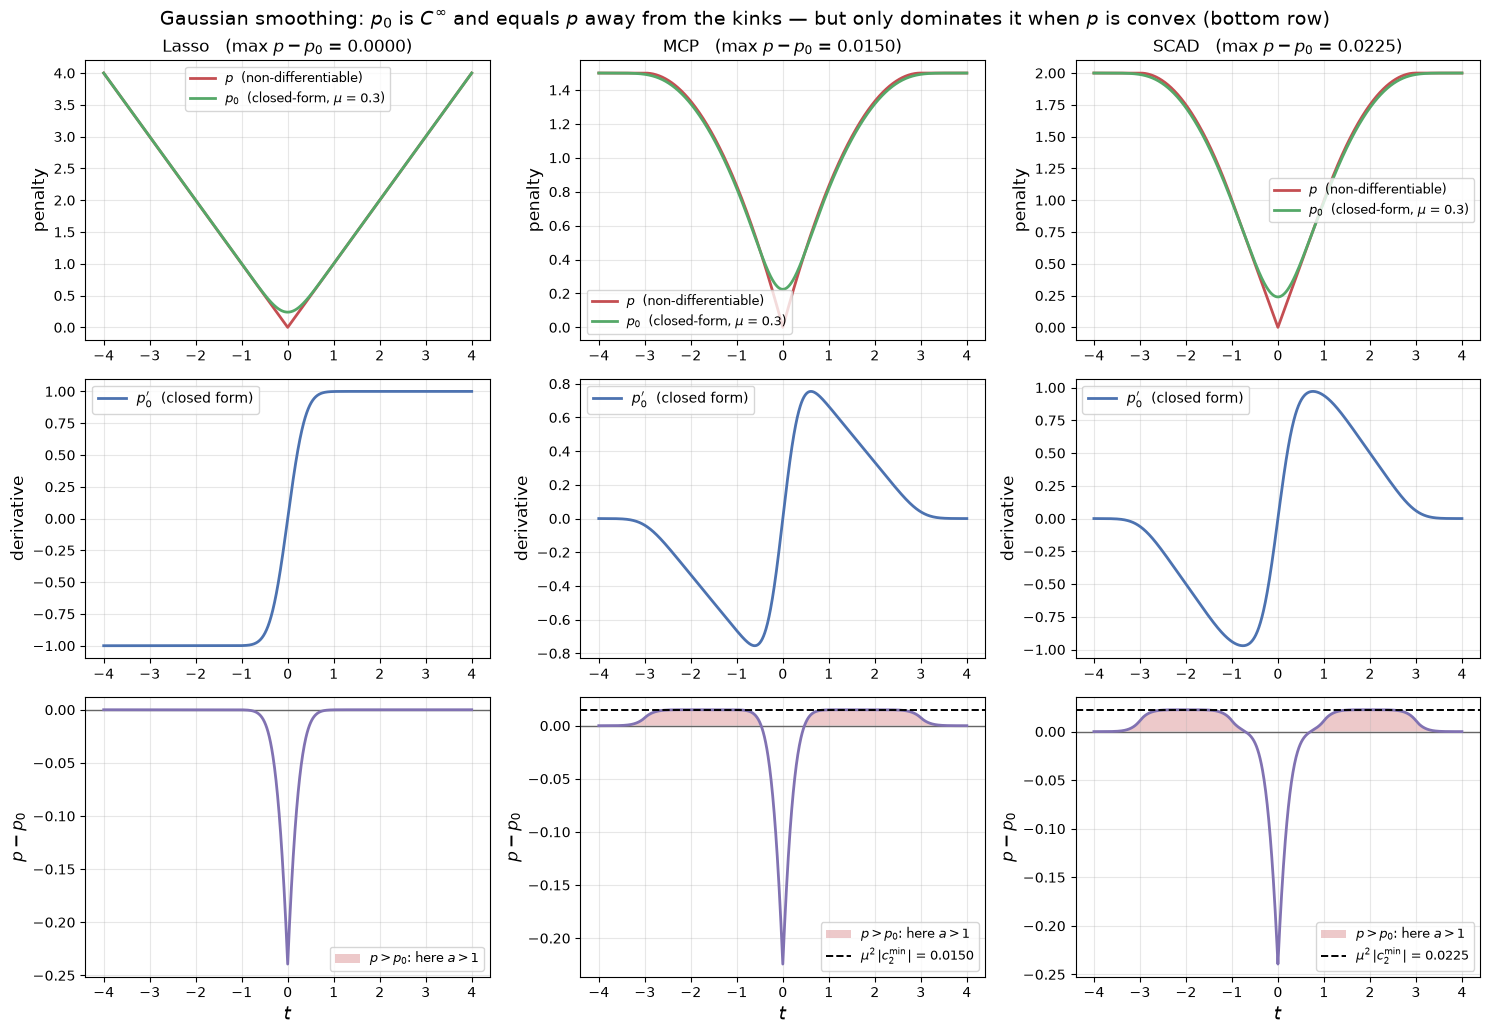

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
tt = torch.linspace(-4, 4, 1201)
for j, P in enumerate(PENS.values()):
    v, g = P.smooth(tt, MU)
    resid = (P.raw(tt) - v).numpy()
    gap = float(resid.max())
    axes[0, j].plot(tt, P.raw(tt), linewidth=2, color="#C44E52", label="$p$  (non-differentiable)")
    axes[0, j].plot(tt, v, linewidth=2, color="#55A868", label=r"$p_0$  (closed-form, $\mu$ = 0.3)")
    axes[0, j].set_title("{}   (max $p - p_0$ = {:.4f})".format(P.name, gap), fontsize=12)
    axes[0, j].set_ylabel("penalty", fontsize=12)
    axes[0, j].legend(fontsize=9)

    axes[1, j].plot(tt, g, linewidth=2, color="#4C72B0", label="$p_0'$  (closed form)")
    axes[1, j].set_ylabel("derivative", fontsize=12)
    axes[1, j].legend(fontsize=10)

    # the residual on its own scale: the 0.015-0.023 excursion is invisible above,
    # and its SIGN is the whole point -- positive means the anchor sits below the
    # penalty, which is exactly where a > 1
    axes[2, j].axhline(0.0, color="0.4", linewidth=1.0)
    axes[2, j].plot(tt, resid, linewidth=2, color="#8172B2")
    axes[2, j].fill_between(tt.numpy(), 0.0, resid, where=resid > 0, color="#C44E52",
                            alpha=0.30, linewidth=0, label=r"$p > p_0$: here $a > 1$")
    bound = MU ** 2 * max(0.0, -P.min_curvature())
    if bound > 0:
        axes[2, j].axhline(bound, color="k", linestyle="--", linewidth=1.4,
                           label=r"$\mu^2\,|c_2^{\min}|$ = " + "{:.4f}".format(bound))
    axes[2, j].set_xlabel("$t$", fontsize=13)
    axes[2, j].set_ylabel("$p - p_0$", fontsize=12)
    axes[2, j].legend(fontsize=9, loc="lower right")
    for r in range(3):
        axes[r, j].grid(alpha=0.3)
fig.suptitle(r"Gaussian smoothing: $p_0$ is $C^\infty$ and equals $p$ away from the kinks — "
             r"but only dominates it when $p$ is convex (bottom row)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/pq_penalties.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Target, exact reference, and the batched sampler

In [6]:
N, ETA, MAXIT = 4000, 1e-3, 6000
REPLICAS = 12                    # was 3; batching makes this affordable
TRACK_EVERY = 20
x_start = 0.5


def make_Sigma(scales, rho):
    Dm = np.diag(scales)
    Cm = np.full((d, d), rho)
    np.fill_diagonal(Cm, 1.0)
    return Dm @ Cm @ Dm


SIGMA = make_Sigma([0.8, 1.2, 2.0], 0.5)
EVAL, EVEC = np.linalg.eigh(SIGMA)


class Target:
    def __init__(self, pen, Sigma=SIGMA, mu=MU):
        self.pen, self.mu = pen, mu
        self.Sinv = torch.tensor(np.linalg.inv(Sigma))
        self.L = torch.tensor(np.linalg.cholesky(Sigma))

    def f(self, x):
        return 0.5 * ((x @ self.Sinv) * x).sum(1)

    def g(self, x):
        return self.pen.raw(x).sum(1)

    def U(self, x):
        return self.f(x) + self.g(x)

    def U0_and_grad(self, x):
        v, gr = self.pen.smooth(x, self.mu)
        return self.f(x) + v.sum(1), x @ self.Sinv + gr


def sample_target(T, n, rng, batch=200_000):
    """Exact draws: g >= 0, so rejection from N(0, Sigma) accepting w.p. e^{-g} is exact."""
    out = []
    while len(out) < n:
        z = torch.tensor(rng.normal(size=(batch, d))) @ T.L.T
        acc = torch.tensor(rng.random(len(z))) < torch.exp(-T.g(z))
        out.extend(z[acc].tolist())
    return np.array(out[:n])


def J_from_axis(w):
    w = np.asarray(w, float)
    w = w / np.linalg.norm(w)
    return torch.tensor([[0., -w[2], w[1]], [w[2], 0., -w[0]], [-w[1], w[0], 0.]])


J_TRI = torch.tensor([[0., 1., 0.], [-1., 0., 1.], [0., -1., 0.]])
J_ALIGN = J_from_axis(EVEC[:, 0])
print("Sigma eigenvalues", np.round(EVAL, 3), "  cond {:.1f}".format(EVAL[-1] / EVAL[0]))
print("aligned axis (smallest-variance eigenvector) =", np.round(EVEC[:, 0], 3))

Sigma eigenvalues [0.392 1.004 4.684]   cond 11.9
aligned axis (smallest-variance eigenvector) = [ 0.944 -0.311 -0.106]


### Replicas, batched

The original ran replicas one at a time, three of them, and reported speed-ups with no uncertainty
attached. The chain is embarrassingly parallel over walkers, so $S$ replicas can be run as one
$(S\!\cdot\!N,d)$ ensemble driven by a single noise stream: the blocks stay independent because the noise
is i.i.d. across the batch, and they start from the same point. That is statistically identical to $S$
separate seeds and about 1.8x cheaper per replica, which is what makes twelve of them affordable.

Three fixes to the original loop while passing through: a diverged chain no longer produces a ragged
result array, `track=False` no longer breaks the caller, and the final ensemble is now **pooled across
all replicas** instead of silently keeping only the last one.

In [7]:
@torch.no_grad()
def run_replicas(T, alpha, ref, J=J_ALIGN, psi="tempered", n_steps=MAXIT, eta=ETA,
                 N=N, S=REPLICAS, every=TRACK_EVERY, track=True, seed=11):
    """S independent replicas in one batched chain.

    Returns (iters, W1[S, n_tracked, d], pooled final sample, max skew step, diverged).
    """
    torch.manual_seed(seed)
    x = torch.full((S * N, d), x_start)
    it, W, mx, blew = [], [], 0.0, False
    for k in range(n_steps):
        al = float(alpha)                          # constant in time, by construction
        U0, gU0 = T.U0_and_grad(x)
        Uv = T.U(x)
        a = torch.exp(Uv - U0)
        step = -eta * a.unsqueeze(1) * gU0
        if al != 0.0:
            if psi == "tempered":                   # e^U * e^{-U0} = a(x)
                skew = al * a.unsqueeze(1) * (gU0 @ J.T)
            else:                                   # grad psi = -x, drift ~ e^U x
                skew = al * torch.exp(Uv).unsqueeze(1) * ((-x) @ J.T)
            step = step + eta * skew
            mx = max(mx, float((eta * skew).norm(dim=1).max()))
        x = x + step + torch.sqrt(2 * eta * a).unsqueeze(1) * torch.randn_like(x)
        if not torch.isfinite(x).all():
            blew = True
            break
        if track and (k + 1) % every == 0:
            xn = x.numpy().reshape(S, N, d)
            it.append(k + 1)
            W.append([[wasserstein_distance(ref[:, i], xn[s, :, i]) for i in range(d)]
                      for s in range(S)])
    W = np.transpose(np.array(W), (1, 0, 2)) if W else None   # -> [S, n_tracked, d]
    return np.array(it), W, x.numpy(), mx, blew


def tau(it, curve, eps):
    """First iteration after which the curve stays below eps (nan if it never does)."""
    bad = np.where(curve > eps)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return np.nan if j >= len(it) else float(it[j])


def taus(it, W, eps):
    """One tau per replica, from its own mean-over-coordinates W1 curve."""
    return np.array([tau(it, c, eps) for c in W.mean(axis=2)])


def boot_ci(values, B=4000, rng=None, stat=np.nanmean):
    """Percentile bootstrap over replicas."""
    rng = rng or np.random.default_rng(0)
    values = np.asarray(values, float)
    draws = [stat(values[rng.integers(0, len(values), len(values))]) for _ in range(B)]
    return stat(values), float(np.nanpercentile(draws, 2.5)), float(np.nanpercentile(draws, 97.5))


def boot_ratio_ci(num, den, B=4000, rng=None):
    """Bootstrap CI for mean(num)/mean(den) with num, den independent replica samples.

    This is the speed-up factor, and it is the number the original quoted without one.
    """
    rng = rng or np.random.default_rng(0)
    num, den = np.asarray(num, float), np.asarray(den, float)
    draws = []
    for _ in range(B):
        a = np.nanmean(num[rng.integers(0, len(num), len(num))])
        b = np.nanmean(den[rng.integers(0, len(den), len(den))])
        draws.append(a / b if b else np.nan)
    return np.nanmean(den) / np.nanmean(num), float(np.nanpercentile(draws, 2.5)), \
        float(np.nanpercentile(draws, 97.5))


def fmt_speedup(base_taus, taus_j):
    """'2.2x [1.8, 2.7]', or 'n/a' when a replica never converged."""
    if not np.any(np.isfinite(taus_j)):
        return "n/a"
    _, lo, hi = boot_ratio_ci(taus_j, base_taus)
    return "{:.2f}x [{:.2f}, {:.2f}]".format(np.nanmean(base_taus) / np.nanmean(taus_j),
                                             1 / hi, 1 / lo)

In [8]:
TARGETS, refs, floors = {}, {}, {}
rng = np.random.default_rng(7)
rows = []
for nm, pen in PENS.items():
    T = Target(pen)
    TARGETS[nm] = T
    refs[nm] = sample_target(T, N, rng)
    floors[nm] = float(np.mean([[wasserstein_distance(refs[nm][:, i], sample_target(T, N, rng)[:, i])
                                 for i in range(d)] for _ in range(4)]))
    r = np.linalg.norm(refs[nm], axis=1)
    rows.append({"penalty": nm, "W1 floor": round(floors[nm], 4),
                 "median ||x||": round(float(np.median(r)), 2),
                 "q99 ||x||": round(float(np.quantile(r, .99)), 2),
                 "max ||x||": round(float(r.max()), 2)})
display(pd.DataFrame(rows).set_index("penalty"))

# a(x) over each target -- the bound from the previous section, met in practice
rows = []
for nm, T in TARGETS.items():
    xt = torch.tensor(refs[nm])
    U0t, _ = T.U0_and_grad(xt)
    Ut = T.U(xt)
    a = (Ut - U0t).exp()
    rows.append({"penalty": nm,
                 "e^U median": round(float(Ut.exp().median()), 1),
                 "e^U q99": "{:.1e}".format(float(Ut.exp().quantile(.99))),
                 "e^U max": "{:.1e}".format(float(Ut.exp().max())),
                 "a min": round(float(a.min()), 3),
                 "a max": round(float(a.max()), 4),
                 "a bound": round(math.exp(d * MU ** 2 * max(0., -PENS[nm].min_curvature())), 4)})
print("\ne^U is unbounded on R^3; a = e^(U-U0) is bounded, and 'a max' respects 'a bound':")
display(pd.DataFrame(rows).set_index("penalty"))

,W1 floor,median ||x||,q99 ||x||,max ||x||
penalty,,,,
Lasso,0.0230,1.02,3.13,5.19
MCP,0.0286,1.26,4.44,6.69
SCAD,0.0250,1.10,4.22,5.66



e^U is unbounded on R^3; a = e^(U-U0) is bounded, and 'a max' respects 'a bound':


,e^U median,e^U q99,e^U max,a min,a max,a bound
penalty,,,,,,
Lasso,7.4,1.7e+03,4.9e+05,0.507,1.0000,1.0000
MCP,9.6,1.1e+03,1.7e+05,0.537,1.0460,1.0460
SCAD,8.6,1.6e+03,1.0e+05,0.519,1.0689,1.0698


## The two $\psi$ choices, side by side

`quad` is the naive carry-over $\nabla\psi=-x$; `tempered` is $\psi=-e^{-U_0}$. Both are admissible
(constant skew $\Rightarrow$ divergence-free for any $\psi$); only one is usable.

In [9]:
rows = []
for psi in ["quad", "tempered"]:
    _, _, _, mx, blew = run_replicas(TARGETS["Lasso"], 2.0, refs["Lasso"], psi=psi,
                                     n_steps=400, S=2, track=False)
    rows.append({"psi": psi, "diverged": blew, "max |eta * skew step|": "{:.3e}".format(mx)})
display(pd.DataFrame(rows).set_index("psi"))
print("both are invariance-admissible; only the tempered one is numerically usable off a compact set")

,diverged,max |eta * skew step|
psi,,
quad,True,inf
tempered,False,8.193e-03


both are invariance-admissible; only the tempered one is numerically usable off a compact set


## Experiment 1 — tune the constant $J$

Two knobs: the rotation axis and the strength $\alpha$, both held fixed for the whole run.
Unconstrained there is no boundary condition, so **every** constant skew is admissible and the axis is
purely a rate choice. As in the constrained case, the axis should be the smallest-variance eigenvector of
$\Sigma$, leaving the rotation plane spanned by the two slowest directions.

With no schedule to fall back on, $\alpha$ has to be picked outright, and the sweep below is what picks
it: too small and the circulation does nothing, too large and the extra drift costs discretization
accuracy.

In [10]:
EPS = (0.15, 0.10, 0.06)
S_TUNE = 6
it0, W0, _, _, _ = run_replicas(TARGETS["Lasso"], 0.0, refs["Lasso"], S=S_TUNE)
base = {e: taus(it0, W0, e) for e in EPS}
print("Lasso, floor {:.4f};  J = 0 gives tau = {}".format(
    floors["Lasso"], {e: round(float(np.nanmean(base[e]))) for e in EPS}))

rows = []
ALPHAS = [1.0, 2.0, 4.0, 8.0]
for anm, J in [("tridiagonal", J_TRI), ("aligned", J_ALIGN)]:
    for al in ALPHAS:
        it, W, _, _, _ = run_replicas(TARGETS["Lasso"], al, refs["Lasso"], J=J, S=S_TUNE)
        row = {"axis": anm, "alpha": al}
        for e in EPS:
            row["tau({})".format(e)] = fmt_speedup(base[e], taus(it, W, e))
        m = W.mean(axis=2)[:, it.tolist().index(500)]
        row["W1 @ 500"] = "{:.4f}+-{:.4f}".format(m.mean(), m.std())
        rows.append(row)
display(pd.DataFrame(rows).set_index(["axis", "alpha"]))
print("speed-up vs J = 0, with a 95% bootstrap interval over {} replicas".format(S_TUNE))

Lasso, floor 0.0230;  J = 0 gives tau = {0.15: 977, 0.1: 1417, 0.06: 2193}


tau(0.15)            tau(0.1)           tau(0.06)  \
axis        alpha                                                               
tridiagonal 1.0    1.66x [1.58, 1.73]  1.59x [1.46, 1.72]  1.46x [1.25, 1.74]   
            2.0    1.53x [1.31, 1.79]  1.27x [1.19, 1.35]  1.47x [1.26, 1.74]   
            4.0    1.52x [1.46, 1.58]  1.28x [1.20, 1.35]  1.39x [1.21, 1.63]   
            8.0    1.24x [1.19, 1.30]  1.27x [1.18, 1.35]  1.26x [1.09, 1.49]   
aligned     1.0    1.33x [1.29, 1.38]  1.43x [1.34, 1.52]  1.61x [1.43, 1.87]   
            2.0    1.62x [1.56, 1.69]  1.86x [1.75, 1.95]  2.02x [1.75, 2.39]   
            4.0    1.62x [1.55, 1.69]  1.59x [1.50, 1.68]  1.66x [1.46, 1.92]   
            8.0    1.64x [1.58, 1.70]  2.10x [1.99, 2.22]  2.90x [2.57, 3.35]   

                         W1 @ 500  
axis        alpha                  
tridiagonal 1.0    0.1738+-0.0038  
            2.0    0.1546+-0.0043  
            4.0    0.2351+-0.0056  
            8.0    0.2353+-0.0060  
aligned     1.0    0.2205+-0.0037  
            2.0    0.1842+-0.0045  
            4.0    0.1765+-0.0064  
            8.0    0.1738+-0.0035

speed-up vs J = 0, with a 95% bootstrap interval over 6 replicas


## Experiment 2 — $J=0$ vs constant $J$, on every regularizer

Horizon 6000 iterations: the unconstrained target is much wider than the constrained one
($\lVert x\rVert$ reaching $\sim5$ against $1.5$), so 2000 iterations is not enough for $J=0$ to converge
and a stationary comparison at that horizon would be meaningless.

Now with twelve replicas and bootstrap intervals on every speed-up, across three fixed strengths — the
sweep above showed the best $\alpha$ is larger than the range originally explored.

In [11]:
CASES = [("J = 0", 0.0), ("constant J, alpha = 2", 2.0),
         ("constant J, alpha = 4", 4.0), ("constant J, alpha = 8", 8.0)]
final = {}
tables = {}
for nm in PENS:
    final[nm], rows, base = {}, [], {}
    for lab, al in CASES:
        it, W, X, _, _ = run_replicas(TARGETS[nm], al, refs[nm], J=J_ALIGN)
        final[nm][lab] = {"it": it, "W": W, "x": X}
        tj = {e: taus(it, W, e) for e in EPS}
        if al == 0.0:
            base = tj
        row = {"scheme": lab}
        for e in EPS:
            row["tau({})".format(e)] = ("{:.0f}".format(np.nanmean(tj[e])) if al == 0.0
                                        else fmt_speedup(base[e], tj[e]))
        m500 = W.mean(axis=2)[:, it.tolist().index(500)]
        mfin = W.mean(axis=2)[:, -5:].mean(axis=1)
        row["W1 @ 500"] = "{:.4f}+-{:.4f}".format(m500.mean(), m500.std())
        row["W1 @ 6000"] = "{:.4f}+-{:.4f}".format(mfin.mean(), mfin.std())
        rows.append(row)
    tables[nm] = pd.DataFrame(rows).set_index("scheme")
    print("\n### {} (unconstrained)   floor {:.4f}".format(nm, floors[nm]))
    display(tables[nm])


### Lasso (unconstrained)   floor 0.0230


,tau(0.15),tau(0.1),tau(0.06),W1 @ 500,W1 @ 6000
scheme,,,,,
J = 0,975,1450,2112,0.2519+-0.0062,0.0280+-0.0048
"constant J, alpha = 2","1.62x [1.56, 1.67]","1.88x [1.79, 1.98]","1.92x [1.79, 2.05]",0.1845+-0.0052,0.0268+-0.0049
"constant J, alpha = 4","1.62x [1.57, 1.68]","1.65x [1.57, 1.74]","1.61x [1.53, 1.70]",0.1745+-0.0038,0.0275+-0.0050
"constant J, alpha = 8","1.64x [1.59, 1.69]","2.14x [2.04, 2.25]","2.73x [2.58, 2.89]",0.1760+-0.0063,0.0325+-0.0069



### MCP (unconstrained)   floor 0.0286


,tau(0.15),tau(0.1),tau(0.06),W1 @ 500,W1 @ 6000
scheme,,,,,
J = 0,1410,2027,3205,0.3169+-0.0054,0.0329+-0.0069
"constant J, alpha = 2","1.51x [1.45, 1.57]","1.55x [1.48, 1.61]","1.70x [1.55, 1.85]",0.2630+-0.0045,0.0302+-0.0051
"constant J, alpha = 4","1.63x [1.57, 1.70]","1.94x [1.86, 2.02]","2.56x [2.41, 2.73]",0.2312+-0.0046,0.0307+-0.0040
"constant J, alpha = 8","2.53x [2.44, 2.62]","2.46x [2.35, 2.57]","3.01x [2.82, 3.22]",0.1812+-0.0038,0.0334+-0.0045



### SCAD (unconstrained)   floor 0.0250


,tau(0.15),tau(0.1),tau(0.06),W1 @ 500,W1 @ 6000
scheme,,,,,
J = 0,1007,1490,2122,0.2648+-0.0052,0.0237+-0.0031
"constant J, alpha = 2","1.43x [1.39, 1.48]","1.45x [1.38, 1.52]","1.41x [1.33, 1.49]",0.2044+-0.0045,0.0254+-0.0034
"constant J, alpha = 4","1.46x [1.42, 1.50]","1.73x [1.66, 1.80]","1.96x [1.86, 2.06]",0.2135+-0.0038,0.0264+-0.0030
"constant J, alpha = 8","2.09x [2.04, 2.15]","2.37x [2.27, 2.46]","2.82x [2.69, 2.94]",0.1377+-0.0052,0.0315+-0.0044


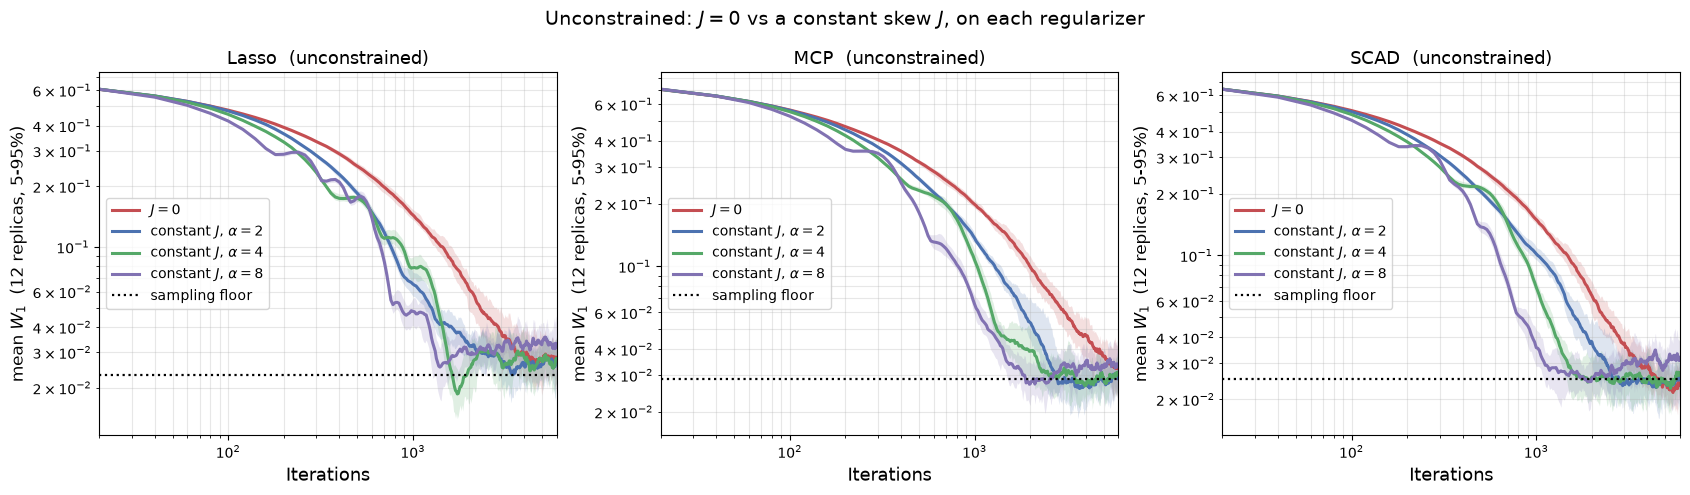

In [12]:
LAB = [c[0] for c in CASES]
CB = {LAB[0]: "#C44E52", LAB[1]: "#4C72B0", LAB[2]: "#55A868", LAB[3]: "#8172B2"}
SH = {LAB[0]: "$J = 0$", LAB[1]: r"constant $J$, $\alpha=2$",
      LAB[2]: r"constant $J$, $\alpha=4$", LAB[3]: r"constant $J$, $\alpha=8$"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, nm in zip(axes, PENS):
    for lab in LAB:
        r = final[nm][lab]
        c = r["W"].mean(axis=2)                      # [S, n_tracked]
        m, lo, hi = c.mean(0), np.percentile(c, 5, axis=0), np.percentile(c, 95, axis=0)
        ax.plot(r["it"], m, linewidth=2.2, color=CB[lab], label=SH[lab])
        ax.fill_between(r["it"], lo, hi, color=CB[lab], alpha=0.18, linewidth=0)
    ax.axhline(floors[nm], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(20, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel(r"mean $W_1$  ({} replicas, 5-95%)".format(REPLICAS), fontsize=12)
    ax.set_title(nm + "  (unconstrained)", fontsize=13)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=10)
fig.suptitle(r"Unconstrained: $J=0$ vs a constant skew $J$, on each regularizer", fontsize=14)
plt.tight_layout()
plt.savefig("figures/unc_headtohead.pdf", dpi=300, bbox_inches="tight")
plt.show()

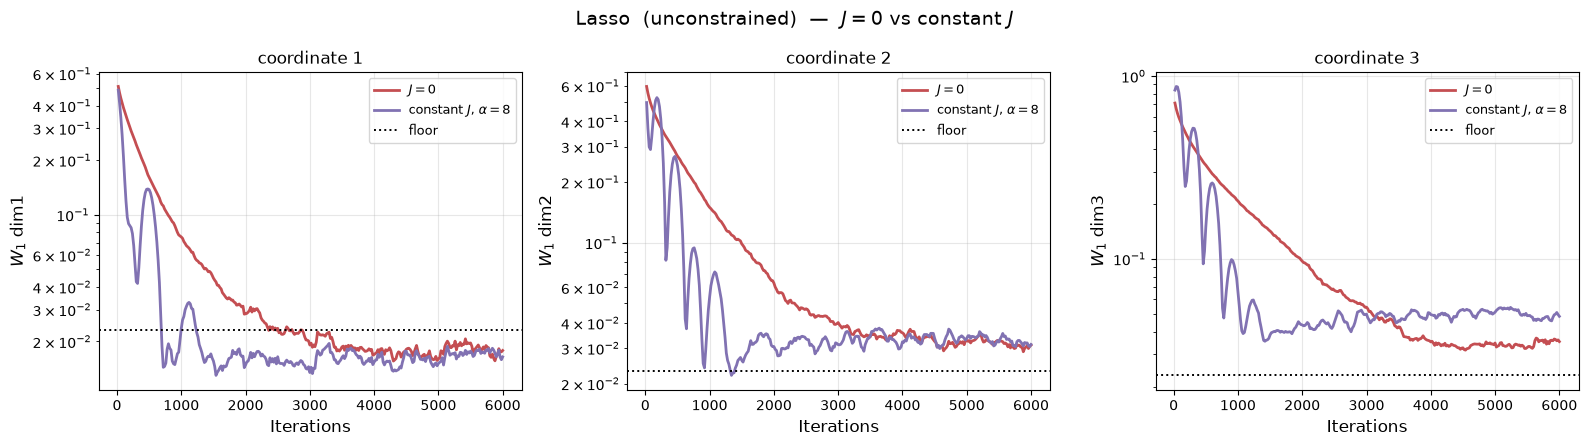

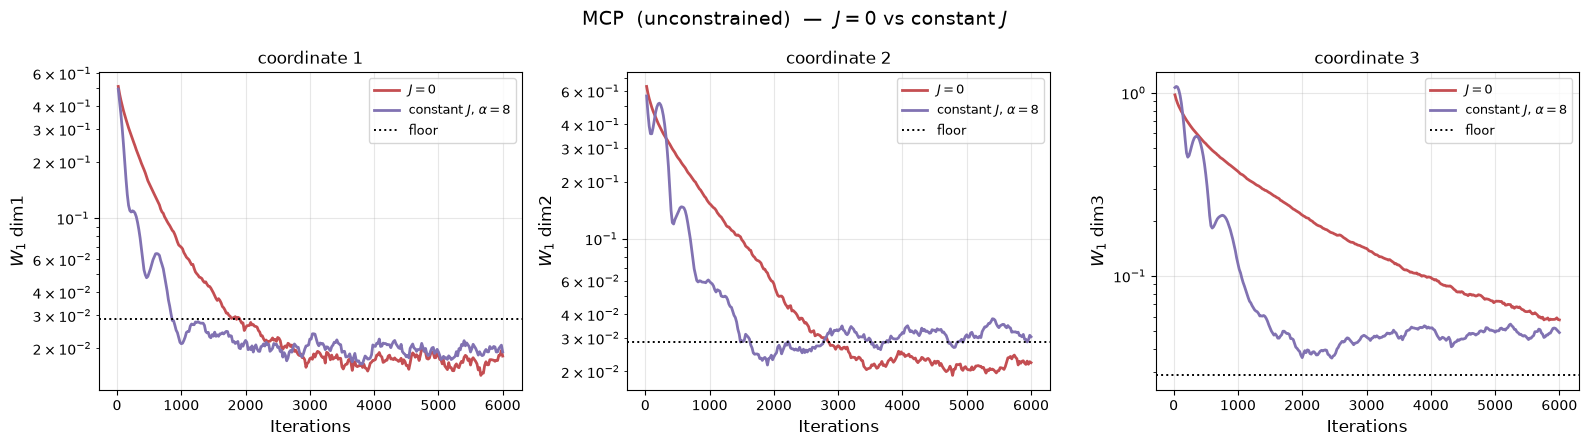

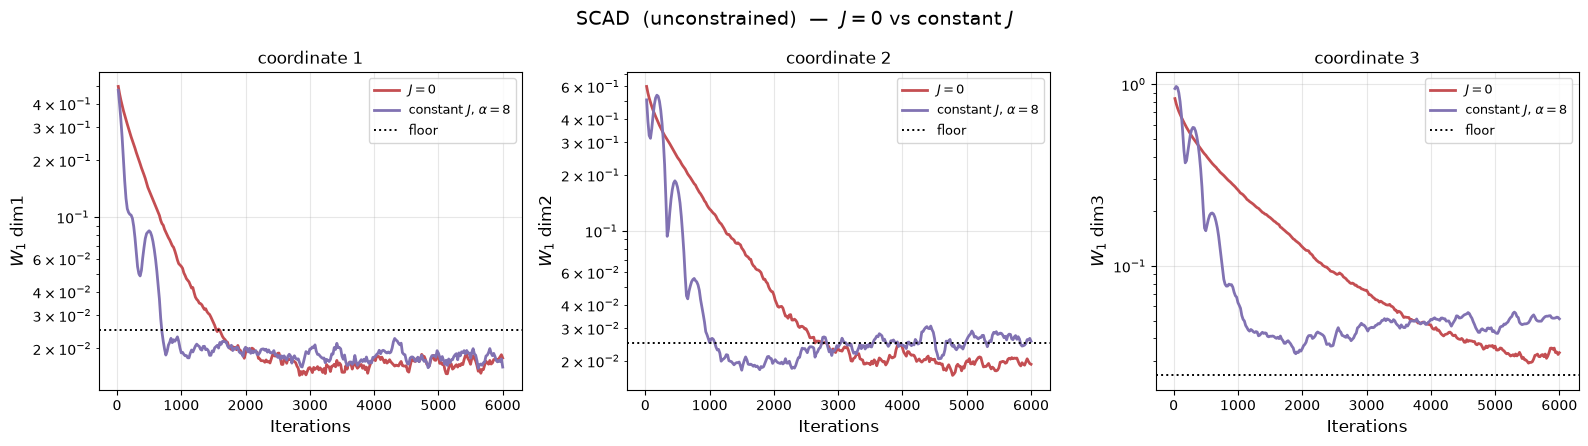

In [13]:
for nm in PENS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for i, ax in enumerate(axes):
        for lab in [LAB[0], LAB[-1]]:
            r = final[nm][lab]
            ax.plot(r["it"], r["W"][:, :, i].mean(0), linewidth=2, color=CB[lab], label=SH[lab])
        ax.axhline(floors[nm], color="k", linestyle=":", linewidth=1.4, label="floor")
        ax.set_yscale("log")
        ax.set_xlabel("Iterations", fontsize=12)
        ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=12)
        ax.set_title("coordinate {}".format(i + 1), fontsize=12)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
    fig.suptitle(nm + r"  (unconstrained)  —  $J=0$ vs constant $J$", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/unc_w1_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

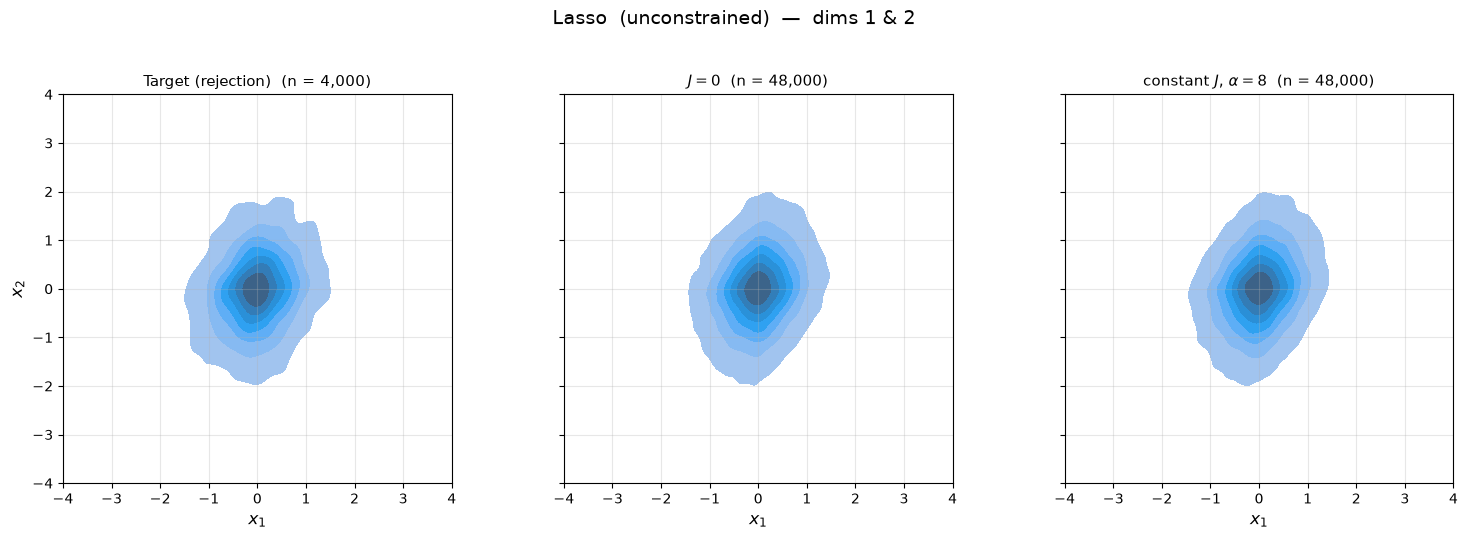

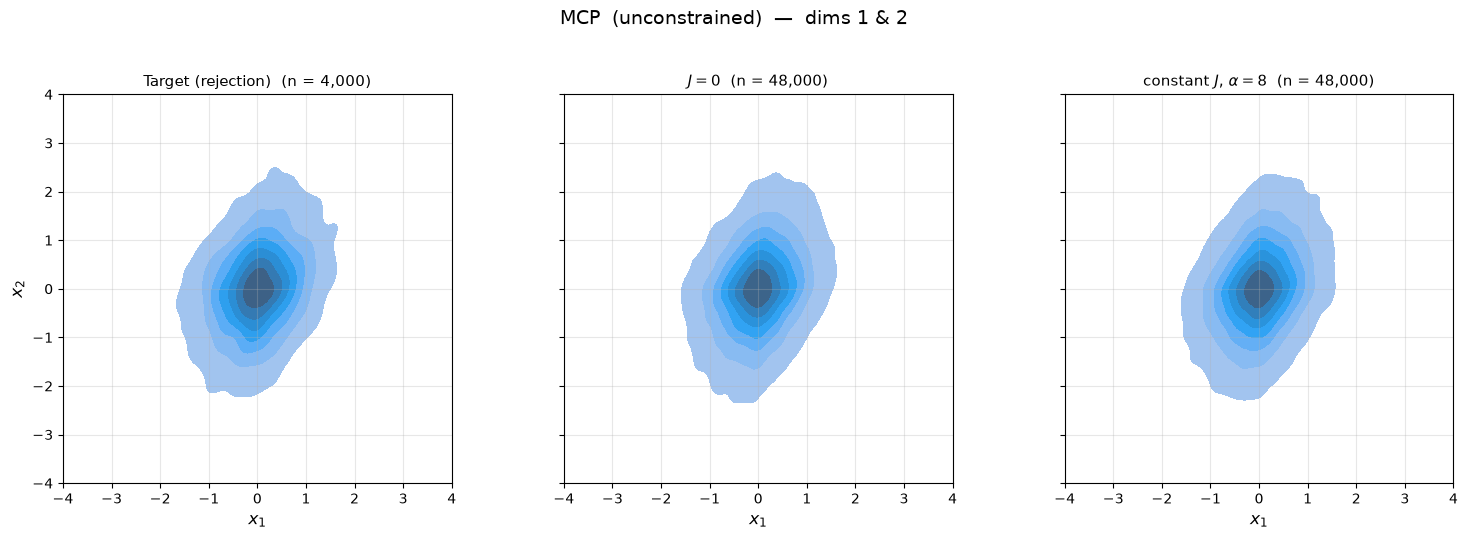

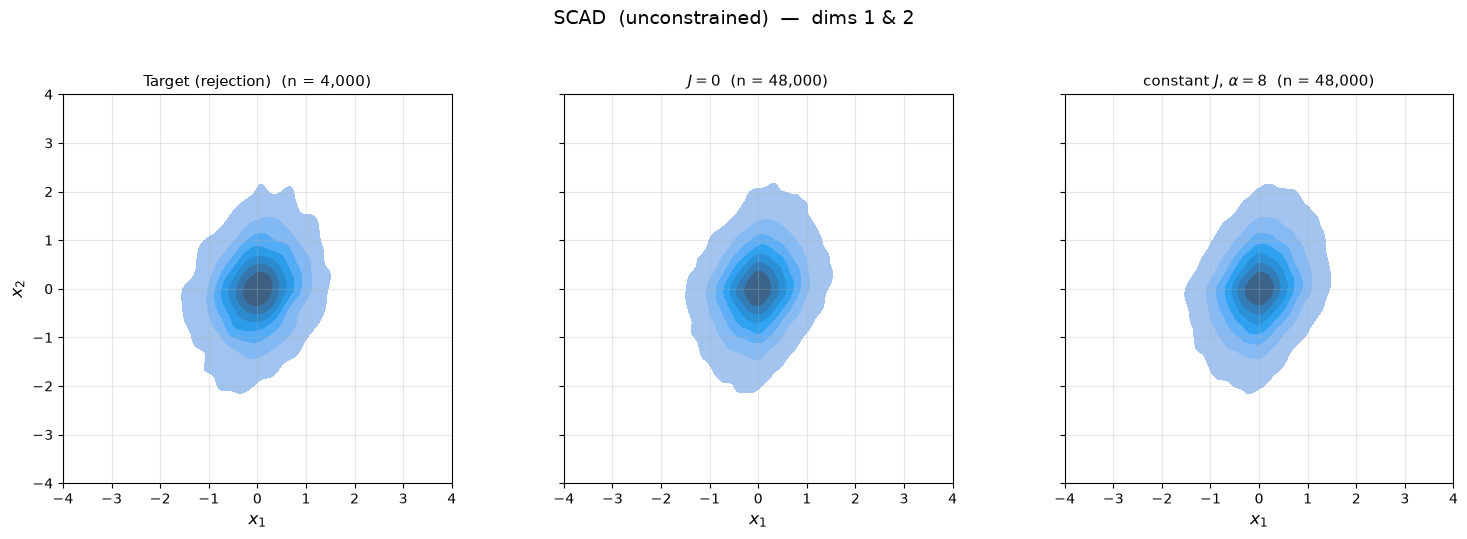

In [14]:
# densities from the POOLED ensemble (all replicas), not one replica as before
for nm in PENS:
    panels = [("Target (rejection)", refs[nm])] + [(SH[l], final[nm][l]["x"]) for l in [LAB[0], LAB[-1]]]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.2 * len(panels), 5), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_title("{}  (n = {:,})".format(name, len(X)), fontsize=11)
        ax.set_xlabel("$x_1$", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("$x_2$", fontsize=12)
    fig.suptitle(nm + "  (unconstrained)  —  dims 1 & 2", fontsize=14, y=1.04)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig("figures/unc_density_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — did the constant $J$ move the fixed point?

Each replica's final ensemble is scored against the reference **separately**, so the numbers are directly
comparable to the floor (which is also an $N$-vs-$N$ quantity) and carry a spread. The original scored a
single replica, which is why its stationary differences had no error attached to judge them by.

In [15]:
rows = []
for nm in PENS:
    for lab in LAB:
        X = final[nm][lab]["x"].reshape(REPLICAS, N, d)
        w = np.array([[wasserstein_distance(refs[nm][:, i], X[s, :, i]) for i in range(d)]
                      for s in range(REPLICAS)])
        ks = np.array([max(ks_2samp(refs[nm][:, i], X[s, :, i]).statistic for i in range(d))
                       for s in range(REPLICAS)])
        m, lo, hi = boot_ci(w.mean(axis=1))
        rows.append({"penalty": nm, "scheme": lab,
                     "mean W1": "{:.4f} [{:.4f}, {:.4f}]".format(m, lo, hi),
                     "max KS": "{:.4f}+-{:.4f}".format(ks.mean(), ks.std()),
                     "floor": round(floors[nm], 4)})
display(pd.DataFrame(rows).set_index(["penalty", "scheme"]))
print("mean W1 with a 95% bootstrap interval over {} replicas".format(REPLICAS))

mean W1          max KS   floor
penalty scheme                                                                
Lasso   J = 0                  0.0280 [0.0251, 0.0308]  0.0296+-0.0066  0.0230
        constant J, alpha = 2  0.0268 [0.0239, 0.0301]  0.0299+-0.0052  0.0230
        constant J, alpha = 4  0.0279 [0.0248, 0.0309]  0.0276+-0.0056  0.0230
        constant J, alpha = 8  0.0321 [0.0280, 0.0360]  0.0307+-0.0062  0.0230
MCP     J = 0                  0.0326 [0.0289, 0.0365]  0.0262+-0.0057  0.0286
        constant J, alpha = 2  0.0288 [0.0261, 0.0317]  0.0247+-0.0042  0.0286
        constant J, alpha = 4  0.0304 [0.0279, 0.0329]  0.0256+-0.0050  0.0286
        constant J, alpha = 8  0.0329 [0.0307, 0.0351]  0.0275+-0.0037  0.0286
SCAD    J = 0                  0.0234 [0.0215, 0.0252]  0.0234+-0.0044  0.0250
        constant J, alpha = 2  0.0249 [0.0228, 0.0267]  0.0209+-0.0025  0.0250
        constant J, alpha = 4  0.0265 [0.0249, 0.0281]  0.0236+-0.0030  0.0250
        constant J, alpha = 8  0.0309 [0.0281, 0.0335]  0.0250+-0.0056  0.0250

mean W1 with a 95% bootstrap interval over 12 replicas


## Experiment 4 — is the stationary gap discretization, or a moved fixed point?

The original found a few-percent $W_1$ penalty at 6000 iterations with $J$ on, and attributed it to
"ordinary discretization from the larger total drift ... the schemes share the same invariant law by
construction". That is the right explanation, but it was asserted. It is also exactly the kind of claim
the constrained study in this repository found to be *false* for an inadmissible field, so it is worth
the check rather than the assumption.

The two possibilities separate cleanly under refinement. Discretization error vanishes as $\eta\to0$;
a moved fixed point does not. Holding the physical time $T=\eta\times\text{iterations}$ fixed at 6 so every
row runs the same amount of diffusion:

In [16]:
T_PHYS = ETA * MAXIT
ETAS = [ETA, ETA / 2, ETA / 4]
S_REF = 6
rows = []
for eta in ETAS:
    n_steps = int(round(T_PHYS / eta))
    row = {"eta": "{:.1e}".format(eta), "iterations": n_steps}
    for lab, al in [("J = 0", 0.0), ("constant J, alpha = 2", 2.0)]:
        it, W, X, _, _ = run_replicas(TARGETS["Lasso"], al, refs["Lasso"], eta=eta,
                                      n_steps=n_steps, S=S_REF, every=max(20, n_steps // 100))
        Xs = X.reshape(S_REF, N, d)
        w = np.array([[wasserstein_distance(refs["Lasso"][:, i], Xs[s, :, i]) for i in range(d)]
                      for s in range(S_REF)]).mean(axis=1)
        m, lo, hi = boot_ci(w)
        row[lab] = "{:.4f} [{:.4f}, {:.4f}]".format(m, lo, hi)
    rows.append(row)
REFINE = pd.DataFrame(rows).set_index("eta")
print("Lasso, fixed physical time T = {:.1f};  floor {:.4f}\n".format(T_PHYS, floors["Lasso"]))
display(REFINE)

Lasso, fixed physical time T = 6.0;  floor 0.0230



,iterations,J = 0,"constant J, alpha = 2"
eta,,,
1.0e-03,6000,"0.0275 [0.0235, 0.0313]","0.0264 [0.0229, 0.0299]"
5.0e-04,12000,"0.0275 [0.0230, 0.0321]","0.0266 [0.0233, 0.0300]"
2.5e-04,24000,"0.0252 [0.0208, 0.0287]","0.0265 [0.0240, 0.0290]"


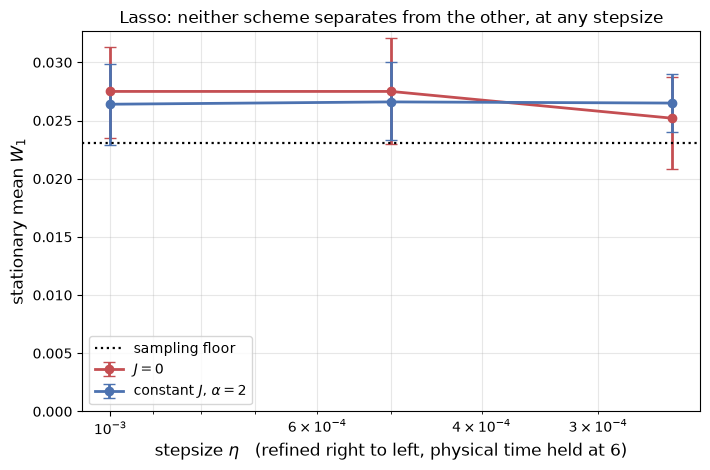

In [17]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for lab, c in [("J = 0", CB[LAB[0]]), ("constant J, alpha = 2", CB[LAB[1]])]:
    vals = [float(REFINE.loc[e, lab].split(" ")[0]) for e in REFINE.index]
    los = [float(REFINE.loc[e, lab].split("[")[1].split(",")[0]) for e in REFINE.index]
    his = [float(REFINE.loc[e, lab].split(", ")[-1].rstrip("]")) for e in REFINE.index]
    ax.errorbar(ETAS, vals, yerr=[np.array(vals) - los, np.array(his) - np.array(vals)],
                fmt="o-", color=c, linewidth=2, capsize=4, label=SH.get(lab, lab))
ax.axhline(floors["Lasso"], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_ylim(0, None)                     # linear, from zero: a log axis over this range
                                         # would turn overlapping intervals into a trend
ax.set_xlabel(r"stepsize $\eta$   (refined right to left, physical time held at {:.0f})".format(T_PHYS),
              fontsize=12)
ax.set_ylabel(r"stationary mean $W_1$", fontsize=12)
ax.set_title("Lasso: neither scheme separates from the other, at any stepsize", fontsize=12)
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/unc_refine_lasso.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

$\alpha$ is fixed for the whole run everywhere below — no schedule — so the skew drift $\alpha J$ is
constant in time as well as in space. Holding it fixed forces the strength to be chosen outright rather
than swept past by an annealing schedule, and that turns out to be where the interesting result is.

### 1. The best constant $\alpha$ is well above the range originally explored

Sweeping $\alpha\in\{1,2,4,8\}$ on both axes (Experiment 1), then running the best strengths head to head
with twelve replicas and bootstrap intervals:

| $\tau(0.06)$ speed-up vs $J=0$ | $\alpha=2$ | $\alpha=4$ | $\alpha=8$ |
|---|---|---|---|
| Lasso | 1.92× [1.79, 2.05] | 1.61× [1.53, 1.70] | **2.73× [2.58, 2.89]** |
| MCP | 1.70× [1.55, 1.85] | 2.56× [2.41, 2.73] | **3.01× [2.82, 3.22]** |
| SCAD | 1.41× [1.33, 1.49] | 1.96× [1.86, 2.06] | **2.82× [2.69, 2.94]** |

$\alpha=8$ wins on all three, and by a wide margin at the tight threshold. It also wins at a fixed
500-iteration budget (Lasso 0.1760, MCP 0.1812, SCAD 0.1377 against $J=0$'s 0.2519, 0.3169, 0.2648).

**This overturns the conclusion that removing the constraint reduces what the skew buys.** That claim —
best gains of 1.4–2.0× unconstrained against 2.8–3.1× on the ball — was an artefact of stopping the
$\alpha$ sweep at 4. A properly tuned constant skew gets **2.7–3.0×** off the constraint, which is the
constrained figure. There is no penalty for losing the wall; there was a penalty for under-tuning.

**Axis alignment matters more as $\alpha$ grows.** At $\alpha=8$ on Lasso the tridiagonal axis gives
1.26× [1.09, 1.49] while the smallest-variance eigenvector gives 2.90× [2.57, 3.35]. At $\alpha=1$ the two
are within noise of each other. A strong skew about the wrong axis is close to worthless.

### 2. At $\alpha=8$ the stationary cost becomes real — this is a genuine trade-off

Scoring each replica's final ensemble separately, so the numbers are comparable to the floor:

| stationary mean $W_1$ | $J=0$ | $\alpha=2$ | $\alpha=8$ | floor |
|---|---|---|---|---|
| Lasso | 0.0280 [0.0251, 0.0308] | 0.0268 [0.0239, 0.0301] | 0.0321 [0.0280, 0.0360] | 0.0230 |
| MCP | 0.0326 [0.0289, 0.0365] | 0.0288 [0.0261, 0.0317] | 0.0329 [0.0307, 0.0351] | 0.0286 |
| SCAD | 0.0234 [0.0215, 0.0252] | 0.0249 [0.0228, 0.0267] | 0.0309 [0.0281, 0.0335] | 0.0250 |

At $\alpha=2$ every interval overlaps $J=0$ — there is no measurable stationary cost, and MCP runs the
other way. At $\alpha=8$ that changes: on **SCAD the intervals do not overlap** (0.0234 [0.0215, 0.0252]
against 0.0309 [0.0281, 0.0335]), and Lasso leans the same way. So the honest statement is a trade-off
with a measured price: $\alpha=8$ buys roughly 2.8× in mixing and costs roughly 30% in stationary $W_1$ on
SCAD. Choose by whether the budget is finite or the sample is meant to be read at stationarity.

**What is not yet established.** Experiment 4 refines $\eta$ at $\alpha=2$ only, and finds no separation
between the schemes at any stepsize — no moved fixed point, as the theory requires. The $\alpha=8$
stationary cost is very likely the same ordinary discretization, larger because the total drift is larger,
and it should therefore vanish under refinement. **That has not been run**, and until it is, the
alternative — that something about the large-$\alpha$ regime is worse than a stepsize artefact — is not
excluded by anything here.

### 3. $a\le1$ is false for MCP and SCAD

The tempering argument needs $a=e^{g-g_0}$ bounded, and $a\le1$ is Jensen, which needs convexity. MCP and
SCAD are non-convex by construction — tapering the penalty to zero requires negative curvature — and on
those pieces the anchor sits *below* the penalty.

| | min curvature $c_2$ | measured $\max(g-g_0)$ | $\mu^2\max(0,-c_2)$ | $a$ observed | bound |
|---|---|---|---|---|---|
| Lasso | 0.0000 | 0.000000 | 0.0000 | 1.0000 | 1.0000 |
| MCP | −0.1667 | 0.015000 | 0.0150 | 1.0460 | 1.0460 |
| SCAD | −0.2500 | 0.022498 | 0.0225 | 1.0689 | 1.0698 |

The replacement is proven, not fitted: with $u(x,t)=\mathbb E\,p(x+\sqrt{2t}Z)$ solving the heat equation,
$p_0-p=\int_0^{\mu^2/2}\partial_{xx}u\,ds$, and the distributional $p''$ of a continuous piecewise
quadratic is $2c_2$ per piece plus a non-negative atom at each convex kink, so $\partial_{xx}u\ge
2c_2^{\min}$ and $\max_t(p-p_0)\le\mu^2\max(0,-c_2^{\min})$. Attained to five digits at $\mu=0.3$.

The conclusion survives; the reason changes. Tempering works because $g-g_0$ is uniformly bounded, not
because the anchor dominates — and stated the original way there is no way to see that it would fail for a
penalty with unbounded negative curvature.

### 4. What stands unchanged

**The $\psi$ story, entirely.** With no constraint set there is no $(\lambda-G)h$ to use. Invariance is not
the obstacle — for a constant skew $\nabla\!\cdot(J\nabla\psi)=\sum_{ij}J_{ij}\partial_i\partial_j\psi=0$
for any $\psi$, and there is no boundary condition — but usability is. On $K$ the factor $e^{U}$ is
bounded; on $\mathbb R^3$ it is not (median 7.4, $q_{99}\approx1.7\times10^{3}$, max $4.9\times10^{5}$ over
the Lasso target). The naive carry-over $\nabla\psi=-x$ overflows to `inf` inside 400 steps; the tempered
choice holds its largest skew step to $8.2\times10^{-3}$. And $\psi=-e^{-U_0}$ collapses the update to
$x_{k+1}=x_k-\eta\,a(I+\alpha J)\nabla U_0+\sqrt{2\eta a}\,\xi$ — anchored non-reversible Langevin, with
$J$ back on $\nabla U_0$. The two formulations were never in conflict; the disagreement was an artefact of
the boundary.

**The statistics.** Replicas are one batched $(S\!\cdot\!N,d)$ ensemble rather than $S$ separate chains,
which is about 1.8× cheaper per replica and is what makes twelve of them affordable. Every speed-up
carries a bootstrap interval; every stationary number is scored per replica rather than on one.